# Cloud Infrastructure Capacity Forecasting with Google TimesFM

## Industry: Cloud Computing

Cloud teams monitor key telemetry like CPU, memory, network, and disk utilization.
Unexpected spikes can overload servers and trigger outages.

This notebook focuses on **CPU utilization forecasting** (5-minute granularity) for a multi-server fleet,
then converts forecasts into autoscaling and cost/outage decisions.

### Forecast goals
- Next hour (`12` steps @ 5min)
- Next 6 hours (`72` steps)
- Next day (`288` steps)

## Data Source (Web Download)

We use real AWS CloudWatch time series from the NAB repository:
- Repository: https://github.com/numenta/NAB
- Folder: `data/realAWSCloudwatch`

Target: multiple `ec2_cpu_utilization_*.csv` files (each file = one server time series).

In [1]:
from __future__ import annotations

import math
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'cloud_capacity' / 'raw'
ART_DIR = PROJECT_ROOT / 'artifacts' / 'cloud_capacity_timesfm'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

CPU_URLS = [
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_77c1ca.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv',
    'https://raw.githubusercontent.com/numenta/NAB/master/data/realAWSCloudwatch/ec2_cpu_utilization_fe7f93.csv',
]

print('Project root:', PROJECT_ROOT)
print('Data dir:', DATA_DIR)
print('Artifacts dir:', ART_DIR)
print('CPU series count:', len(CPU_URLS))

Project root: /home/ahmad/AI/Github/google-TimesFM-implementation
Data dir: /home/ahmad/AI/Github/google-TimesFM-implementation/data/cloud_capacity/raw
Artifacts dir: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/cloud_capacity_timesfm
CPU series count: 8


## 1) Download and Build Multi-Server CPU Panel

In [2]:
def load_cpu_series(url: str) -> pd.DataFrame:
    sid = url.split('/')[-1].replace('.csv', '')
    local_path = DATA_DIR / f'{sid}.csv'

    if local_path.exists():
        df = pd.read_csv(local_path, parse_dates=['timestamp'])
    else:
        df = pd.read_csv(url, parse_dates=['timestamp'])
        df.to_csv(local_path, index=False)

    df = df.rename(columns={'value': 'cpu_utilization'})
    df['server_id'] = sid
    return df


parts = [load_cpu_series(u) for u in CPU_URLS]
raw_panel = pd.concat(parts, ignore_index=True)

# Regularize each server to strict 5-minute cadence.
regular = []
for sid, g in raw_panel.groupby('server_id'):
    x = (
        g.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
        .asfreq('5min')
    )
    x['cpu_utilization'] = x['cpu_utilization'].interpolate(limit_direction='both')
    x['cpu_utilization'] = x['cpu_utilization'].clip(lower=0, upper=100)
    x = x.reset_index()
    x['server_id'] = sid
    regular.append(x)

panel = pd.concat(regular, ignore_index=True)

print('Raw rows:', len(raw_panel))
print('Panel rows:', len(panel))
print('Servers:', panel['server_id'].nunique())
print('Range:', panel['timestamp'].min(), '->', panel['timestamp'].max())
panel.head()

Raw rows: 32256
Panel rows: 32263
Servers: 8
Range: 2014-02-14 14:27:00 -> 2014-04-24 00:09:00


,timestamp,cpu_utilization,server_id
0,2014-02-14 14:30:00,0.132,ec2_cpu_utilization_24ae8d
1,2014-02-14 14:35:00,0.134,ec2_cpu_utilization_24ae8d
2,2014-02-14 14:40:00,0.134,ec2_cpu_utilization_24ae8d
3,2014-02-14 14:45:00,0.134,ec2_cpu_utilization_24ae8d
4,2014-02-14 14:50:00,0.134,ec2_cpu_utilization_24ae8d


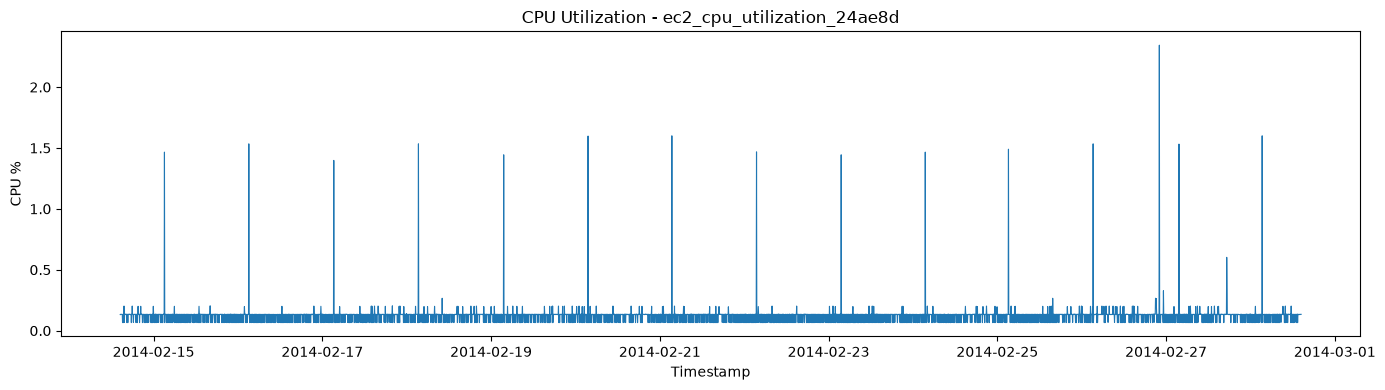

In [3]:
sample_server = panel['server_id'].iloc[0]
plot_df = panel[panel['server_id'] == sample_server]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df['timestamp'], plot_df['cpu_utilization'], lw=0.8)
ax.set_title(f'CPU Utilization - {sample_server}')
ax.set_ylabel('CPU %')
ax.set_xlabel('Timestamp')
plt.tight_layout()
plt.show()

## 2) Configure Forecasting Task

In [4]:
@dataclass
class Config:
    context_len: int = 576          # 2 days of 5-min observations
    max_horizon: int = 288          # 1 day ahead (5-min steps)
    eval_horizons: tuple[int, ...] = (12, 72, 288)  # 1h, 6h, 24h
    # anchor offsets (steps from latest point): 7d, 5d, 3d, 2d
    anchor_offsets: tuple[int, ...] = (2016, 1440, 864, 576)
    per_core_batch_size: int = 8
    xreg_mode: str = 'xreg + timesfm'
    xreg_ridge: float = 1e-3


cfg = Config()

series_map = {
    sid: g.sort_values('timestamp').reset_index(drop=True)
    for sid, g in panel.groupby('server_id')
}

print('Series prepared:', len(series_map))

Series prepared: 8


## 3) Load TimesFM

In [5]:
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
fc = timesfm.ForecastConfig(
    max_context=cfg.context_len,
    max_horizon=cfg.max_horizon,
    normalize_inputs=True,
    per_core_batch_size=cfg.per_core_batch_size,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
)
model.compile(fc)
print('TimesFM compiled.')

TimesFM compiled.


In [6]:
def build_time_covariates(start_ts: pd.Timestamp, context_len: int, horizon: int) -> dict[str, list[list[float]]]:
    idx = pd.date_range(start_ts, periods=context_len + horizon, freq='5min')
    minute_of_day = (idx.hour * 60 + idx.minute).astype(np.float32)
    dow = idx.dayofweek.astype(np.float32)

    return {
        'tod_sin': [np.sin(2 * np.pi * minute_of_day / (24 * 60)).astype(np.float32).tolist()],
        'tod_cos': [np.cos(2 * np.pi * minute_of_day / (24 * 60)).astype(np.float32).tolist()],
        'dow_sin': [np.sin(2 * np.pi * dow / 7).astype(np.float32).tolist()],
        'dow_cos': [np.cos(2 * np.pi * dow / 7).astype(np.float32).tolist()],
        'is_weekend': [(dow >= 5).astype(np.float32).tolist()],
    }


def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8))

## 4) Rolling Backtest (TimesFM vs Baselines)

Baselines:
- `naive_last`
- `seasonal_day` (same 5-minute slot previous day)

In [7]:
metric_rows = []

for offset in cfg.anchor_offsets:
    inputs = []
    dyn = {k: [] for k in ['tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'is_weekend']}
    meta = []

    for sid, ts in series_map.items():
        n = len(ts)
        end = n - 1 - offset
        if end - cfg.context_len + 1 < 0 or end + cfg.max_horizon >= n:
            continue

        context = ts['cpu_utilization'].iloc[end - cfg.context_len + 1 : end + 1].to_numpy(np.float32)
        future = ts['cpu_utilization'].iloc[end + 1 : end + cfg.max_horizon + 1].to_numpy(np.float32)
        start_ts = ts['timestamp'].iloc[end - cfg.context_len + 1]

        cov = build_time_covariates(start_ts, cfg.context_len, cfg.max_horizon)
        inputs.append(context)
        for k in dyn:
            dyn[k].append(cov[k][0])

        meta.append((sid, future, float(context[-1]), context[-288:].copy()))

    if not inputs:
        continue

    try:
        point, _ = model.forecast_with_covariates(
            inputs=inputs,
            dynamic_numerical_covariates=dyn,
            xreg_mode=cfg.xreg_mode,
            ridge=cfg.xreg_ridge,
        )
        pred_batch = np.asarray(point, dtype=np.float32)
    except Exception:
        point, _ = model.forecast(horizon=cfg.max_horizon, inputs=inputs)
        pred_batch = np.asarray(point, dtype=np.float32)

    pred_batch = np.clip(pred_batch, 0.0, 100.0)

    for i, (sid, y_true, last_val, last_day) in enumerate(meta):
        p_tfm = pred_batch[i, : cfg.max_horizon]
        p_last = np.repeat(last_val, cfg.max_horizon)
        p_seasonal = np.tile(last_day, math.ceil(cfg.max_horizon / 288))[: cfg.max_horizon]

        for hz in cfg.eval_horizons:
            y = y_true[:hz]
            for name, p in {
                'timesfm': p_tfm[:hz],
                'naive_last': p_last[:hz],
                'seasonal_day': p_seasonal[:hz],
            }.items():
                metric_rows.append(
                    {
                        'server_id': sid,
                        'anchor_offset': offset,
                        'horizon_steps': hz,
                        'model': name,
                        'mae': mean_absolute_error(y, p),
                        'rmse': mean_squared_error(y, p) ** 0.5,
                        'wmape': wmape(y, p),
                    }
                )

metrics = (
    pd.DataFrame(metric_rows)
    .groupby(['horizon_steps', 'model'], as_index=False)[['mae', 'rmse', 'wmape']]
    .mean()
    .sort_values(['horizon_steps', 'rmse'])
)
metrics

,horizon_steps,model,mae,rmse,wmape
2,12,timesfm,1.626911,2.119255,0.352971
1,12,seasonal_day,2.570052,3.561465,0.257616
0,12,naive_last,4.226828,4.624192,0.477333
5,72,timesfm,2.455773,4.557883,0.269812
3,72,naive_last,4.599679,6.613870,0.451363
4,72,seasonal_day,4.519854,7.976397,0.456526
8,288,timesfm,3.867386,7.001042,0.312314
6,288,naive_last,6.332594,9.163775,0.530941
7,288,seasonal_day,5.709891,9.805152,0.428384


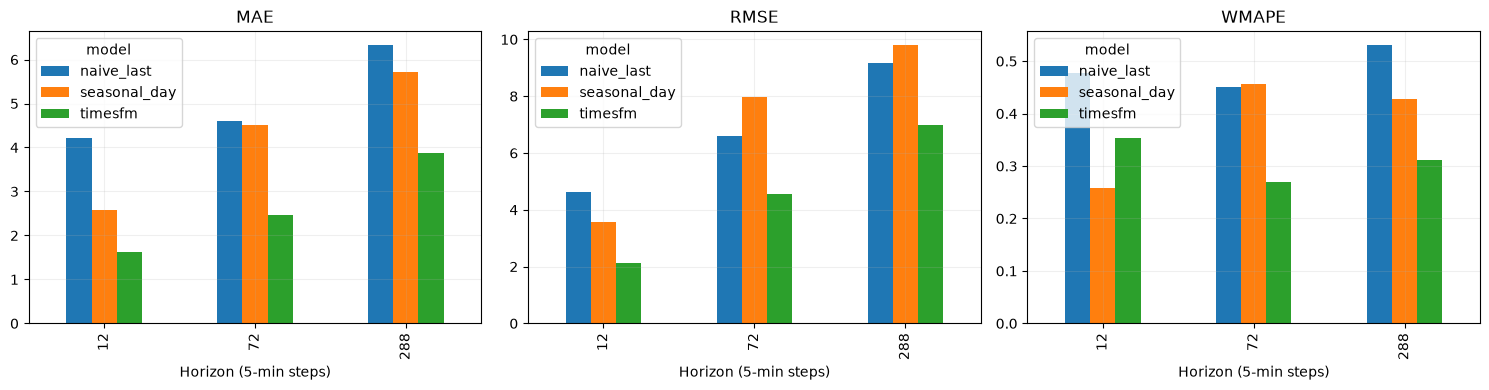

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, metric in zip(axes, ['mae', 'rmse', 'wmape']):
    p = metrics.pivot(index='horizon_steps', columns='model', values=metric)
    p.plot(kind='bar', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Horizon (5-min steps)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5) Forecast Next 24 Hours for Each Server

In [9]:
inputs = []
dyn = {k: [] for k in ['tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'is_weekend']}
meta = []

for sid, ts in series_map.items():
    if len(ts) < cfg.context_len + cfg.max_horizon:
        continue

    context = ts['cpu_utilization'].iloc[-cfg.context_len:].to_numpy(np.float32)
    start_ts = ts['timestamp'].iloc[-cfg.context_len]
    anchor_ts = ts['timestamp'].iloc[-1]

    cov = build_time_covariates(start_ts, cfg.context_len, cfg.max_horizon)
    inputs.append(context)
    for k in dyn:
        dyn[k].append(cov[k][0])
    meta.append((sid, anchor_ts, float(context[-1])))

try:
    point, quant = model.forecast_with_covariates(
        inputs=inputs,
        dynamic_numerical_covariates=dyn,
        xreg_mode=cfg.xreg_mode,
        ridge=cfg.xreg_ridge,
    )
    point_np = np.asarray(point, dtype=np.float32)
    quant_np = np.asarray(quant, dtype=np.float32)
except Exception:
    point, quant = model.forecast(horizon=cfg.max_horizon, inputs=inputs)
    point_np = np.asarray(point, dtype=np.float32)
    quant_np = np.asarray(quant, dtype=np.float32)

point_np = np.clip(point_np, 0.0, 100.0)
quant_np = np.clip(quant_np, 0.0, 100.0)

rows = []
for i, (sid, anchor_ts, last_cpu) in enumerate(meta):
    fut_idx = pd.date_range(anchor_ts + pd.Timedelta(minutes=5), periods=cfg.max_horizon, freq='5min')
    for h, ts_f in enumerate(fut_idx, start=1):
        rows.append(
            {
                'server_id': sid,
                'forecast_ts': ts_f,
                'horizon_step': h,
                'cpu_p50': float(point_np[i, h - 1]),
                'cpu_q10': float(quant_np[i, h - 1, 1]),
                'cpu_q90': float(quant_np[i, h - 1, 9]),
                'last_cpu': last_cpu,
            }
        )

forecast_df = pd.DataFrame(rows)
forecast_df.head()

,server_id,forecast_ts,horizon_step,cpu_p50,cpu_q10,cpu_q90,last_cpu
0,ec2_cpu_utilization_24ae8d,2014-02-28 14:30:00,1,0.130715,0.105102,0.138328,0.134
1,ec2_cpu_utilization_24ae8d,2014-02-28 14:35:00,2,0.131479,0.102782,0.138774,0.134
2,ec2_cpu_utilization_24ae8d,2014-02-28 14:40:00,3,0.130879,0.098998,0.137270,0.134
3,ec2_cpu_utilization_24ae8d,2014-02-28 14:45:00,4,0.133069,0.099767,0.138727,0.134
4,ec2_cpu_utilization_24ae8d,2014-02-28 14:50:00,5,0.131710,0.096658,0.137511,0.134


## 6) Capacity Planning: Autoscale, Cost, and Outage Risk

Assumptions (editable):
- Current fleet size = number of servers in dataset
- Target CPU under autoscaling = 60%
- Risk threshold = 85%
- Instance cost = $0.096 per instance-hour

We compare:
- **Static policy:** no autoscaling
- **Forecast policy:** scale using `q90` utilization forecast

In [10]:
cluster = (
    forecast_df.groupby('horizon_step', as_index=False)
    .agg(
        cpu_p50=('cpu_p50', 'mean'),
        cpu_q90=('cpu_q90', 'mean'),
    )
    .sort_values('horizon_step')
)

base_ts = forecast_df['forecast_ts'].min()
cluster['forecast_ts'] = base_ts + pd.to_timedelta((cluster['horizon_step'] - 1) * 5, unit='m')

current_instances = int(forecast_df['server_id'].nunique())
target_cpu = 60.0
risk_threshold = 85.0
instance_hour_cost = 0.096
step_hours = 5.0 / 60.0

# Estimated fleet size needed so q90 utilization falls near target.
cluster['instances_needed'] = np.ceil((current_instances * cluster['cpu_q90'] / 100.0) / (target_cpu / 100.0)).astype(int)
cluster['instances_needed'] = cluster['instances_needed'].clip(lower=1)

# Utilization after scaling (q90 risk view)
cluster['cpu_q90_after_scale'] = (cluster['cpu_q90'] * current_instances / cluster['instances_needed']).clip(upper=100.0)

# Cost (next 24h horizon)
h24 = cluster[cluster['horizon_step'] <= 288].copy()

static_cost = current_instances * instance_hour_cost * 24.0
autoscaled_cost = float((h24['instances_needed'] * instance_hour_cost * step_hours).sum())
cost_savings = static_cost - autoscaled_cost

# Outage-risk proxy: time steps above threshold
risk_static_steps = int((h24['cpu_q90'] > risk_threshold).sum())
risk_scaled_steps = int((h24['cpu_q90_after_scale'] > risk_threshold).sum())

kpis = pd.DataFrame(
    [
        {
            'current_instances': current_instances,
            'static_cost_24h_usd': static_cost,
            'autoscaled_cost_24h_usd': autoscaled_cost,
            'cost_savings_24h_usd': cost_savings,
            'risk_static_steps': risk_static_steps,
            'risk_scaled_steps': risk_scaled_steps,
        }
    ]
)

kpis

,current_instances,static_cost_24h_usd,autoscaled_cost_24h_usd,cost_savings_24h_usd,risk_static_steps,risk_scaled_steps
0,8,18.432,11.52,6.912,0,0


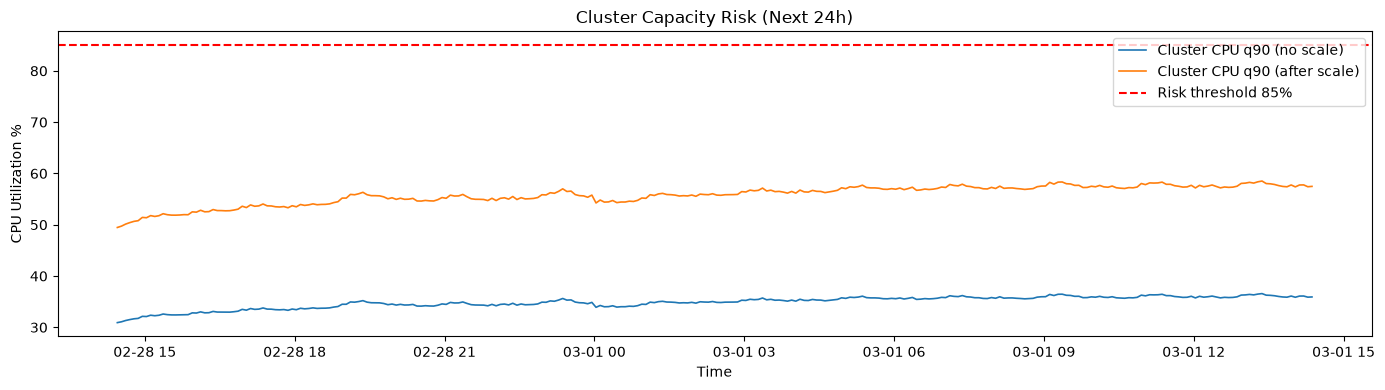

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(h24['forecast_ts'], h24['cpu_q90'], label='Cluster CPU q90 (no scale)', lw=1.2)
ax.plot(h24['forecast_ts'], h24['cpu_q90_after_scale'], label='Cluster CPU q90 (after scale)', lw=1.2)
ax.axhline(85, color='red', linestyle='--', label='Risk threshold 85%')
ax.set_title('Cluster Capacity Risk (Next 24h)')
ax.set_ylabel('CPU Utilization %')
ax.set_xlabel('Time')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [12]:
metrics_path = ART_DIR / 'backtest_metrics.csv'
forecast_path = ART_DIR / 'server_forecast_next_24h.csv'
cluster_plan_path = ART_DIR / 'cluster_capacity_plan_24h.csv'
kpis_path = ART_DIR / 'autoscaling_kpis.csv'

metrics.to_csv(metrics_path, index=False)
forecast_df.to_csv(forecast_path, index=False)
h24.to_csv(cluster_plan_path, index=False)
kpis.to_csv(kpis_path, index=False)

print('Saved:', metrics_path)
print('Saved:', forecast_path)
print('Saved:', cluster_plan_path)
print('Saved:', kpis_path)

Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/cloud_capacity_timesfm/backtest_metrics.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/cloud_capacity_timesfm/server_forecast_next_24h.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/cloud_capacity_timesfm/cluster_capacity_plan_24h.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/cloud_capacity_timesfm/autoscaling_kpis.csv


## Final Outputs

This notebook delivers:
1. CPU utilization forecasts for the next hour, 6 hours, and 24 hours.
2. An autoscaling plan driven by uncertainty-aware (`q90`) forecasts.
3. Cost comparison of static vs forecast-driven scaling.
4. Outage-risk proxy before and after autoscaling.

For production, feed live telemetry into this pipeline on a rolling schedule (e.g., every 5 minutes) and apply guardrails for minimum/maximum instance counts and scaling cooldown windows.